In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("student_health_data_m.csv")

In [3]:
df.head()

,user_id,gender,age,unit_system,height,weight,steps_per_day,BMI,sleep_hours
0,U003,Male,29.0,Metric,178.9,80.2,6483.0,25.1,6.0
1,U005,Male,27.0,Metric,162.8,64.3,NaN,24.3,5.5
2,U006,Female,21.0,Metric,NaN,73.8,4286.0,26.4,4.0
3,U008,Male,NaN,Metric,176.2,87.0,5420.0,28.0,5.1
4,U009,Male,29.0,Metric,182.5,76.5,9121.0,23.0,7.5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   user_id        100 non-null    object 
 1   gender         91 non-null     object 
 2   age            86 non-null     float64
 3   unit_system    100 non-null    object 
 4   height         83 non-null     float64
 5   weight         95 non-null     float64
 6   steps_per_day  95 non-null     float64
 7   BMI            87 non-null     float64
 8   sleep_hours    100 non-null    float64
dtypes: float64(6), object(3)
memory usage: 7.2+ KB


In [5]:
df.describe()

,age,height,weight,steps_per_day,BMI,sleep_hours
count,86.000000,83.000000,95.000000,95.000000,87.000000,100.000000
mean,24.162791,124.371084,118.664211,6174.852632,24.548276,5.847000
std,3.524237,53.824406,54.082878,3947.159488,5.700466,1.274732
min,18.000000,58.000000,48.600000,501.000000,3.300000,3.000000
25%,21.000000,66.100000,68.500000,4243.000000,22.350000,5.000000
50%,25.000000,158.200000,91.100000,5520.000000,24.500000,5.800000
75%,27.000000,171.650000,166.850000,7604.500000,27.400000,6.800000
max,29.000000,225.000000,253.400000,30000.000000,36.800000,9.500000


In [6]:
df.groupby('unit_system')[['height', 'weight']].mean()

,height,weight
unit_system,,
Metric,169.772093,68.433333
US,75.565000,169.963830


In [7]:
df.groupby('unit_system')[['height', 'weight']].describe()

height                                                          \
             count        mean        std    min      25%     50%      75%   
unit_system                                                                  
Metric        43.0  169.772093   8.820413  150.6  163.000  170.70  176.150   
US            40.0   75.565000  35.940375   58.0   62.575   65.95   69.725   

                   weight                                               \
               max  count        mean        std    min     25%    50%   
unit_system                                                              
Metric       187.8   48.0   68.433333  10.102650   48.6   59.65   68.5   
US           225.0   47.0  169.963830  23.475551  116.6  157.65  167.4   

                            
                75%    max  
unit_system                 
Metric        76.35   91.1  
US           183.65  253.4

In [8]:
import matplotlib.pyplot as plt

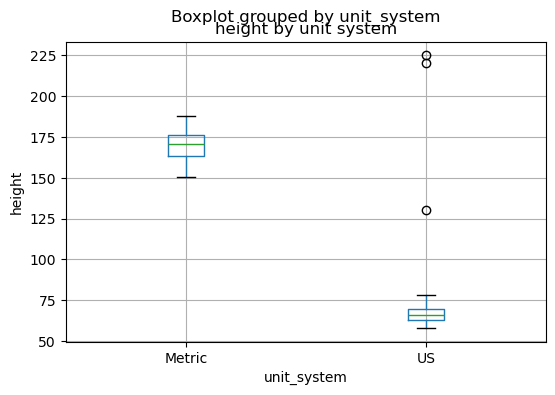

In [9]:
df.boxplot(column='height', by='unit_system', figsize=(6,4))
plt.title("height by unit system")
plt.ylabel('height')
plt.show()

In [10]:
import seaborn as sns

numeric_cols = ['height', 'weight', 'steps_per_day', 'BMI']
corr_matrix = df[numeric_cols].corr()

print(corr_matrix.round(2))

               height  weight  steps_per_day   BMI
height           1.00   -0.72           0.13 -0.52
weight          -0.72    1.00          -0.09  0.15
steps_per_day    0.13   -0.09           1.00 -0.19
BMI             -0.52    0.15          -0.19  1.00


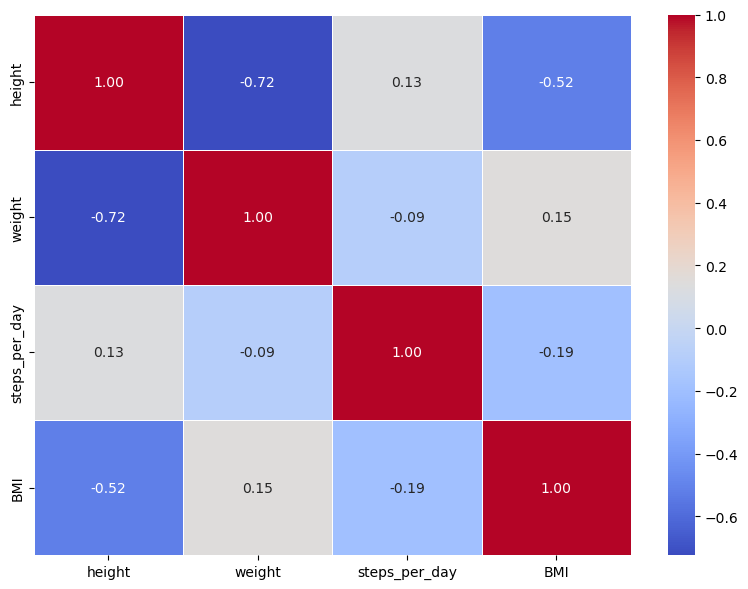

In [11]:
plt.figure(figsize=(8,6 ))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.tight_layout()
plt.show()

In [12]:
import numpy as np

In [13]:
df_converted = df.copy()
us_mask = df_converted['unit_system'] == 'US'

print(us_mask)

0     False
1     False
2     False
3     False
4     False
      ...  
95     True
96     True
97     True
98     True
99     True
Name: unit_system, Length: 100, dtype: bool


In [14]:
df_converted.loc[us_mask, 'height'] = df_converted.loc[us_mask, 'height'] * 2.5 
df_converted.loc[us_mask, 'weight'] = df_converted.loc[us_mask, 'weight'] * 0.45

In [15]:
df_clean = df_converted[['height', 'weight']].dropna()

In [16]:
print(df_clean.head())

   height  weight
0   178.9    80.2
1   162.8    64.3
3   176.2    87.0
4   182.5    76.5
5   170.7    68.7


In [17]:
df = df_converted
df = df.drop(columns=["unit_system"])

corr_matrix = df[numeric_cols].corr()

print(corr_matrix.round(2))

               height  weight  steps_per_day   BMI
height           1.00    0.55           0.08 -0.72
weight           0.55    1.00          -0.06  0.10
steps_per_day    0.08   -0.06           1.00 -0.19
BMI             -0.72    0.10          -0.19  1.00


In [18]:
def detect_outliers(df, column):
    mean = df[column].mean()
    std = df[column].std()
    lower_bound = mean - 2 * std
    higher_bound = mean + 2 * std
    return df[(df[column] < lower_bound) | (df[column] > higher_bound)]

height_outliers = detect_outliers(df, 'height')


In [19]:
print(height_outliers)

   user_id  gender   age  height   weight  steps_per_day  BMI  sleep_hours
53    U007    Male  25.0   325.0   92.790         3836.0  8.6          5.0
59    U027  Female  18.0   562.5  114.030         8295.0  3.5          8.0
93    U087  Female  20.0   550.0  100.845            NaN  3.3          6.5


In [20]:
print(height_outliers.head())

   user_id  gender   age  height   weight  steps_per_day  BMI  sleep_hours
53    U007    Male  25.0   325.0   92.790         3836.0  8.6          5.0
59    U027  Female  18.0   562.5  114.030         8295.0  3.5          8.0
93    U087  Female  20.0   550.0  100.845            NaN  3.3          6.5


In [21]:
h_outliers = ['U007', 'U027', 'U087']

non_outliers_heights = df[~df['user_id'].isin(['U007', 'U027', 'U087'])]['height']

mean_height = non_outliers_heights.mean()


In [22]:

df_clean = df.dropna(subset=['height', 'weight', 'steps_per_day', 'sleep_hours'])

## Option 1: Removing Outliers

In [23]:
# List of user_ids to be removed due to implausible height
outlier_ids = ['U007', 'U027', 'U087']

# Remove the outliers from the dataset
df_removed_outliers = df[~df['user_id'].isin(outlier_ids)].copy()

# Drop any rows with missing values
df_option1 = df_removed_outliers.dropna(subset=['height', 'weight', 'steps_per_day', 'sleep_hours'])

print(f"Original dataset size: {len(df)}")
print(f"After removing outliers: {len(df_option1)}")
print(f"Rows removed: {len(df) - len(df_option1)}")

Original dataset size: 100
After removing outliers: 77
Rows removed: 23


## Option 2: Replacing Outliers by Mean Value

In [24]:
# Create a copy of the original dataset
df_mean_replaced = df.copy()

# Calculate mean height (excluding the outliers to be fair)
non_outlier_heights = df_mean_replaced[~df_mean_replaced['user_id'].isin(['U007', 'U027', 'U087'])]['height']
mean_height = non_outlier_heights.mean()

# Replace height values for the 3 outlier records with the mean
outlier_ids = ['U007', 'U027', 'U087']
df_mean_replaced.loc[df_mean_replaced['user_id'].isin(outlier_ids), 'height'] = round(mean_height, 1)

# Drop any rows with missing values
df_option2 = df_mean_replaced.dropna(subset=['height', 'weight', 'steps_per_day', 'sleep_hours'])

print(f"Original dataset size: {len(df)}")
print(f"After replacing outliers with mean: {len(df_option2)}")
print(f"Mean height used for replacement: {mean_height:.2f}")
print(f"Rows with missing values removed: {len(df) - len(df_option2)}")

Original dataset size: 100
After replacing outliers with mean: 79
Mean height used for replacement: 167.74
Rows with missing values removed: 21


## Option 3: Replacing Outliers by Median

In [25]:
# Create a copy of the original dataset
df_median_replaced = df.copy()

# Calculate median height (excluding the outliers to be fair)
non_outlier_heights = df_median_replaced[~df_median_replaced['user_id'].isin(['U007', 'U027', 'U087'])]['height']
median_height = non_outlier_heights.median()

# Replace height values for the 3 outlier records with the median
outlier_ids = ['U007', 'U027', 'U087']
df_median_replaced.loc[df_median_replaced['user_id'].isin(outlier_ids), 'height'] = round(median_height, 1)

# Drop any rows with missing values
df_option3 = df_median_replaced.dropna(subset=['height', 'weight', 'steps_per_day', 'sleep_hours'])

print(f"Original dataset size: {len(df)}")
print(f"After replacing outliers with median: {len(df_option3)}")
print(f"Median height used for replacement: {median_height:.2f}")
print(f"Rows with missing values removed: {len(df) - len(df_option3)}")

Original dataset size: 100
After replacing outliers with median: 79
Median height used for replacement: 167.85
Rows with missing values removed: 21
